In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [48]:
df = pd.read_csv('/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/ML Micro Projects/data/raw/nyc_energy_consumption.csv')

In [49]:
df

,timeStamp,demand,precip,temp
0,2012-01-01 00:00:00,4937.5,0.0000,46.13
1,2012-01-01 01:00:00,4752.1,0.0000,45.89
2,2012-01-01 02:00:00,4542.6,0.0000,45.04
3,2012-01-01 03:00:00,4357.7,0.0000,45.03
4,2012-01-01 04:00:00,4275.5,0.0000,42.61
...,...,...,...,...
49200,2017-08-12 02:00:00,NaN,0.0000,70.84
49201,2017-08-12 03:00:00,NaN,0.0000,70.57
49202,2017-08-12 04:00:00,NaN,0.0000,69.89
49203,2017-08-12 05:00:00,NaN,0.0000,68.59


In [50]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

In [51]:
fig = px.line(df, x='timeStamp', y='demand', title='NYC Energy Consumption Over Time')

fig.update_xaxes(
    rangeslider_visible = True,
    rangeselector=dict(
        buttons = list([
            dict(count = 1, label="1y", step = "year", stepmode = "backward"),
            dict(count = 2, label="2y", step = "year", stepmode = "backward"),
            dict(count = 3, label="3y", step = "year", stepmode = "backward")
        ])
    )
)
fig.show()


In [52]:
ny_df = df.set_index('timeStamp')

array([<Axes: xlabel='timeStamp'>, <Axes: xlabel='timeStamp'>,
       <Axes: xlabel='timeStamp'>], dtype=object)

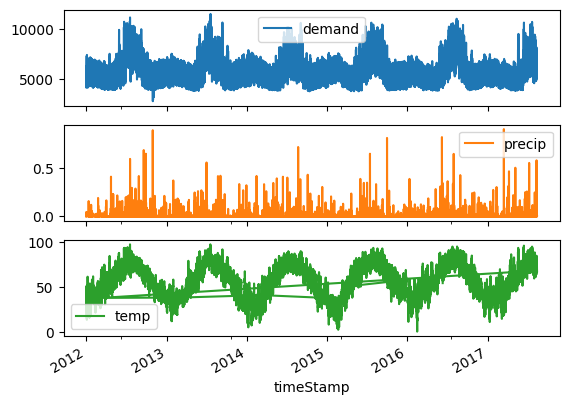

In [53]:
ny_df.plot(subplots=True)

In [54]:
ny_df

,demand,precip,temp
timeStamp,,,
2012-01-01 00:00:00,4937.5,0.0000,46.13
2012-01-01 01:00:00,4752.1,0.0000,45.89
2012-01-01 02:00:00,4542.6,0.0000,45.04
2012-01-01 03:00:00,4357.7,0.0000,45.03
2012-01-01 04:00:00,4275.5,0.0000,42.61
...,...,...,...
2017-08-12 02:00:00,NaN,0.0000,70.84
2017-08-12 03:00:00,NaN,0.0000,70.57
2017-08-12 04:00:00,NaN,0.0000,69.89


In [55]:
ny_df.resample('D').mean()

,demand,precip,temp
timeStamp,,,
2012-01-01,4954.833333,0.002487,46.510000
2012-01-02,5302.954167,0.000000,40.496667
2012-01-03,6095.512500,0.000000,26.672500
2012-01-04,6336.266667,0.000000,20.585000
2012-01-05,6130.245833,0.000000,33.577500
...,...,...,...
2017-08-08,6471.626042,0.000000,71.039167
2017-08-09,6811.112167,0.047529,73.852500
2017-08-10,5582.297000,0.002033,75.217500


array([<Axes: xlabel='timeStamp'>, <Axes: xlabel='timeStamp'>,
       <Axes: xlabel='timeStamp'>], dtype=object)

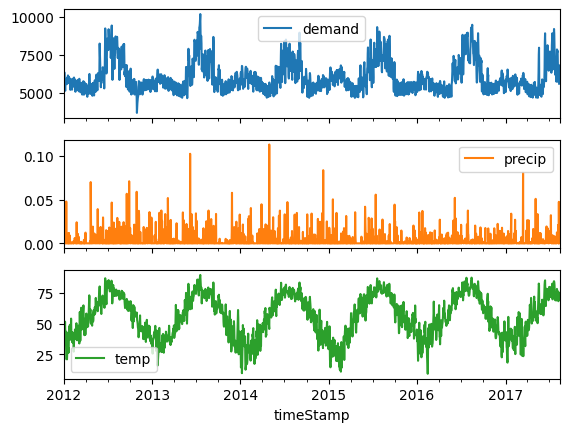

In [56]:
ny_df.resample('D').mean().plot(subplots=True)

In [57]:
ny_df_daily = ny_df.resample('D').mean()

In [58]:
from prophet import Prophet

In [59]:
ny_df_final = ny_df_daily.reset_index()[['timeStamp', 'demand']].rename({'timeStamp' : 'ds', 'demand' : 'y'}, axis=1)

In [60]:
ny_df_final

,ds,y
0,2012-01-01,4954.833333
1,2012-01-02,5302.954167
2,2012-01-03,6095.512500
3,2012-01-04,6336.266667
4,2012-01-05,6130.245833
...,...,...
2046,2017-08-08,6471.626042
2047,2017-08-09,6811.112167
2048,2017-08-10,5582.297000
2049,2017-08-11,NaN


In [61]:
train = ny_df_final[(ny_df_final['ds'] >= '2012-01-01') & (ny_df_final['ds'] <= '2017-04-30')]
test = ny_df_final[(ny_df_final['ds'] > '2017-04-30')]

In [62]:
train.shape

(1947, 2)

In [63]:
test.shape

(104, 2)

In [64]:
test

,ds,y
1947,2017-05-01,5417.231583
1948,2017-05-02,5697.950042
1949,2017-05-03,5354.628500
1950,2017-05-04,5235.704833
1951,2017-05-05,5358.639500
...,...,...
2046,2017-08-08,6471.626042
2047,2017-08-09,6811.112167
2048,2017-08-10,5582.297000
2049,2017-08-11,NaN


In [65]:
m = Prophet(interval_width=0.95, yearly_seasonality=True)

In [66]:
m.fit(train)

11:41:21 - cmdstanpy - INFO - Chain [1] start processing
11:41:21 - cmdstanpy - INFO - Chain [1] done processing
11:41:21 - cmdstanpy - INFO - Chain [1] done processing


In [67]:
m.params

OrderedDict([('lp__', array([[5008.86]])),
             ('k', array([[0.0661555]])),
             ('m', array([[0.594991]])),
             ('delta',
              array([[-8.62336e-08, -8.25715e-03, -6.69154e-02, -3.56537e-04,
                       8.18044e-09, -1.15747e-08,  1.86964e-08, -1.09353e-07,
                      -1.24778e-07, -2.78684e-07, -4.20706e-02, -4.74545e-02,
                      -4.95735e-06, -1.16858e-07,  1.72649e-01,  4.44389e-02,
                      -2.46391e-08, -6.77339e-02, -6.03455e-02,  6.78302e-08,
                      -4.89534e-08,  1.52921e-08,  1.17086e-02,  2.21236e-03,
                       7.73196e-08]])),
             ('sigma_obs', array([[0.0460382]])),
             ('beta',
              array([[-0.0347312 , -0.0704621 ,  0.0575634 ,  0.0470468 , -0.0140682 ,
                      -0.00499821, -0.00389564, -0.00073365,  0.00240313, -0.00756604,
                       0.00403654,  0.00482887, -0.00790763, -0.00470835,  0.00700649,
          

In [68]:
future = m.make_future_dataframe(periods = 104)
future.tail()

,ds
2046,2017-08-08
2047,2017-08-09
2048,2017-08-10
2049,2017-08-11
2050,2017-08-12


In [69]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
2046,2017-08-08,7589.643068,6695.291542,8514.381979
2047,2017-08-09,7578.811419,6766.197581,8494.037827
2048,2017-08-10,7533.585429,6630.090334,8409.608632
2049,2017-08-11,7488.860749,6580.982282,8364.540244
2050,2017-08-12,6914.100251,6055.373752,7842.738926


<Axes: xlabel='ds'>

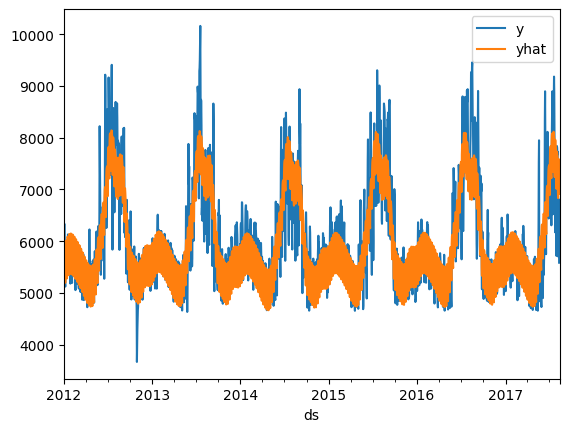

In [70]:
pd.concat([ny_df_final.set_index('ds')['y'], forecast.set_index('ds')['yhat']], axis = 1).plot()

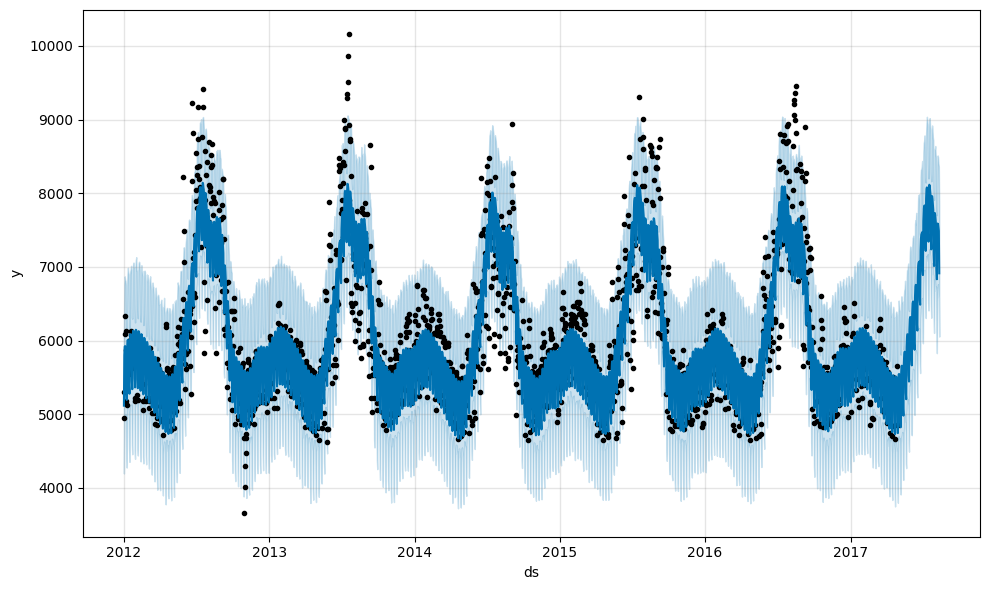

In [71]:
fig1 = m.plot(forecast)

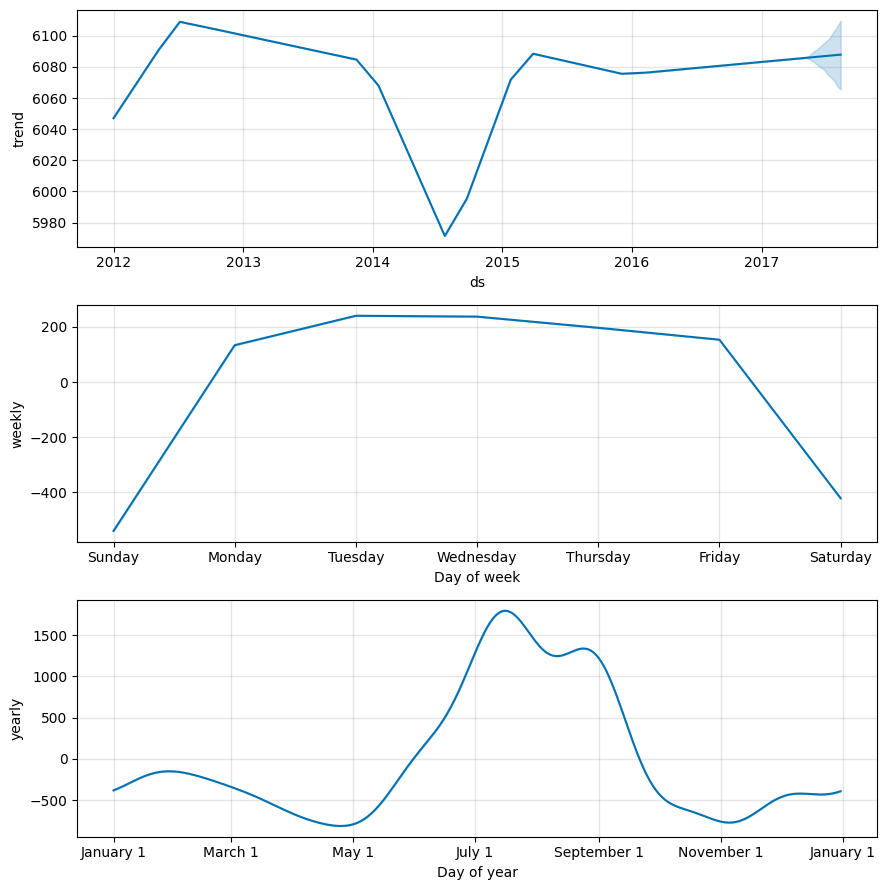

In [72]:
fig2 = m.plot_components(forecast)

In [73]:
from prophet.plot import add_changepoints_to_plot

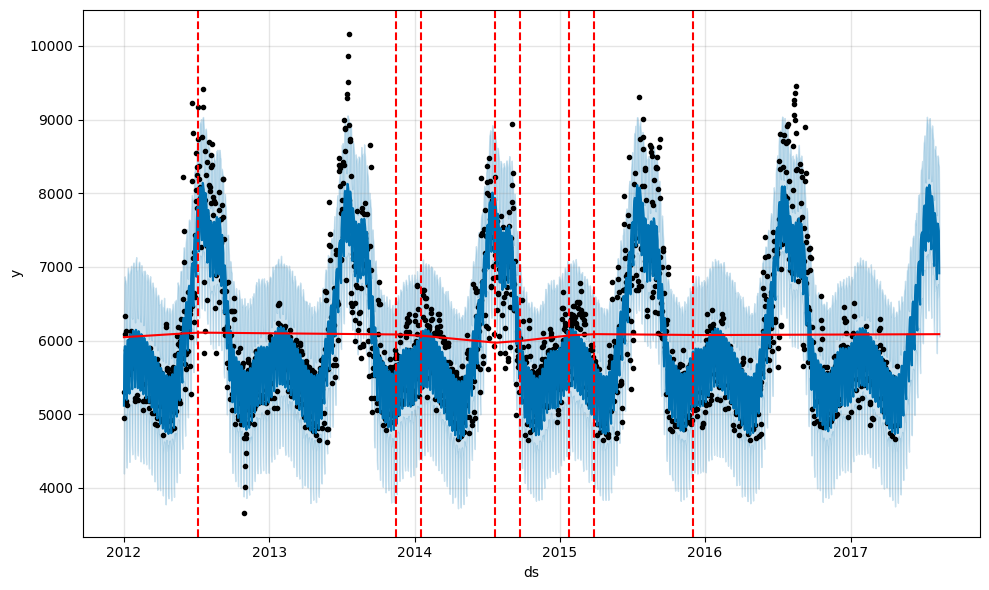

In [74]:
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)

In [75]:
deltas = m.params['delta'].mean(0)
deltas

array([-8.62336e-08, -8.25715e-03, -6.69154e-02, -3.56537e-04,
        8.18044e-09, -1.15747e-08,  1.86964e-08, -1.09353e-07,
       -1.24778e-07, -2.78684e-07, -4.20706e-02, -4.74545e-02,
       -4.95735e-06, -1.16858e-07,  1.72649e-01,  4.44389e-02,
       -2.46391e-08, -6.77339e-02, -6.03455e-02,  6.78302e-08,
       -4.89534e-08,  1.52921e-08,  1.17086e-02,  2.21236e-03,
        7.73196e-08])

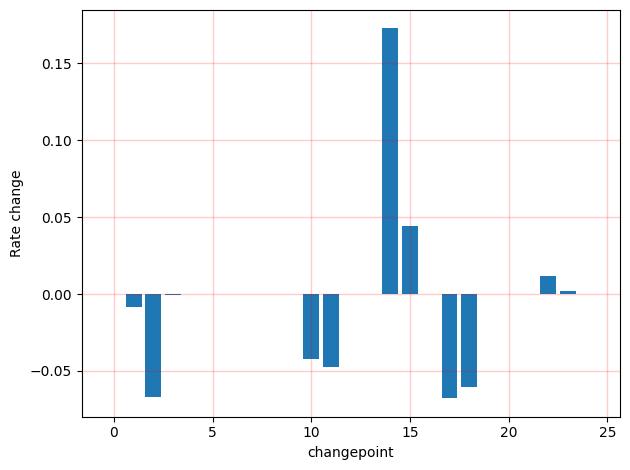

In [76]:
fig = plt.figure(facecolor = 'w')
ax = fig.add_subplot(111) 
ax.bar(range(len(deltas)), deltas)
ax.grid(True, which='major', c = 'red', ls='-', lw=1, alpha=0.2)
ax.set_ylabel('Rate change')
ax.set_xlabel('changepoint')
fig.tight_layout()

In [77]:
m.changepoints

62     2012-03-03
124    2012-05-04
187    2012-07-06
249    2012-09-06
311    2012-11-07
373    2013-01-08
436    2013-03-12
498    2013-05-13
560    2013-07-14
622    2013-09-14
685    2013-11-16
747    2014-01-17
809    2014-03-20
871    2014-05-21
934    2014-07-23
996    2014-09-23
1058   2014-11-24
1120   2015-01-25
1183   2015-03-29
1245   2015-05-30
1307   2015-07-31
1369   2015-10-01
1432   2015-12-03
1494   2016-02-03
1556   2016-04-05
Name: ds, dtype: datetime64[ns]